# GeoAI Aquaculture Pond Identification Challenge
## Machine Learning & AI Trustworthiness Pipeline

This notebook implements the complete workflow to detect aquaculture ponds from space using Sentinel-1 (SAR) and Sentinel-2 (optical) satellite data. It includes:
1. **Exploratory Data Analysis (EDA):** Visualizing class distributions, geographical boundaries, spectral responses, and temporal signatures of ponds.
2. **Feature Engineering:** Extracting spectral indices (NDVI, NDWI, MNDWI, LSWI, EVI), SAR ratios (VV-VH, RVI), and seasonal temporal statistics (min, max, mean, std).
3. **Machine Learning Pipeline:** Building an ensemble of XGBoost, LightGBM, and CatBoost models trained under 5-Fold Stratified Cross-Validation.
4. **Ensemble Blending:** Optimizing weights to maximize Zindi's metric: $0.6 \times \text{F1-Score(threshold=0.5)} + 0.4 \times \text{ROC-AUC}$.
5. **AI Trustworthiness Evaluation:** A detailed discussion on bias, model transparency (SHAP feature importances), reusability, and training sustainability/efficiency.

In [10]:
# Setup & Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.cluster import KMeans
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import ee
import time
import warnings
warnings.filterwarnings('ignore')
# Set aesthetics for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## 1. Load Data
Let's load the training and testing datasets and examine their sizes and target class balance.

In [11]:
# Load Data (with GEE Extraction Fallback)
try:
    ee.Initialize(project='capable-arbor-452015-b3')
    print("Earth Engine initialized successfully!")
except Exception as e:
    print(f"Earth Engine initialization failed: {e}")
# Check if GEE features are already cached
if os.path.exists('Train_gee.csv') and os.path.exists('Test_gee.csv'):
    print("Loading pre-extracted GEE features from CSV...")
    train = pd.read_csv('Train_gee.csv')
    test = pd.read_csv('Test_gee.csv')
else:
    print("Pre-extracted GEE features not found. Extracting from Earth Engine...")
    train = pd.read_csv('Train.csv')
    test = pd.read_csv('Test.csv')
    
    # Combine coordinates for extraction
    df = pd.concat([train[['ID', 'lon', 'lat']], test[['ID', 'lon', 'lat']]], axis=0).reset_index(drop=True)
    min_lon, max_lon = df['lon'].min() - 0.05, df['lon'].max() + 0.05
    min_lat, max_lat = df['lat'].min() - 0.05, df['lat'].max() + 0.05
    geom_bounds = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
    
    # Create ee.FeatureCollection
    features = []
    for idx, row in df.iterrows():
        geom = ee.Geometry.Point([row['lon'], row['lat']])
        feat = ee.Feature(geom, {'ID': row['ID']})
        features.append(feat)
    fc = ee.FeatureCollection(features)
    
    result_df = pd.DataFrame({'ID': df['ID']})
    
    # Extract year-by-year embeddings
    years = [2021, 2022, 2023]
    for yr in years:
        print(f"Extracting Satellite Embeddings for year {yr}...")
        img = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
            .filterDate(f'{yr}-01-01', f'{yr}-12-31') \
            .filterBounds(geom_bounds) \
            .mosaic()
        band_names = [f'embed_{yr}_A{i:02d}' for i in range(64)]
        old_names = [f'A{i:02d}' for i in range(64)]
        img = img.select(old_names, band_names)
        sampled_fc = img.reduceRegions(collection=fc, reducer=ee.Reducer.first(), scale=10)
        res = sampled_fc.getInfo()
        extracted = [feat['properties'] for feat in res['features']]
        yr_df = pd.DataFrame(extracted)
        result_df = result_df.merge(yr_df, on='ID', how='left')
        
    # Extract ESA WorldCover
    print("Extracting ESA WorldCover features...")
    esa_2020 = ee.ImageCollection('ESA/WorldCover/v100').filterBounds(geom_bounds).first().select(['Map'], ['esa_wc_2020'])
    esa_2021 = ee.ImageCollection('ESA/WorldCover/v200').filterBounds(geom_bounds).first().select(['Map'], ['esa_wc_2021'])
    esa_img = esa_2020.addBands(esa_2021)
    sampled_fc = esa_img.reduceRegions(collection=fc, reducer=ee.Reducer.first(), scale=10)
    res = sampled_fc.getInfo()
    extracted = [feat['properties'] for feat in res['features']]
    esa_df = pd.DataFrame(extracted)
    result_df = result_df.merge(esa_df, on='ID', how='left')
    
    # Merge and save
    train = train.merge(result_df, on='ID', how='left')
    test = test.merge(result_df, on='ID', how='left')
    train.to_csv('Train_gee.csv', index=False)
    test.to_csv('Test_gee.csv', index=False)
    print("Saved extracted GEE features to Train_gee.csv and Test_gee.csv")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
print("\nClass balance in Train:")
print(train['label'].value_counts(normalize=True))


Earth Engine initialized successfully!
Loading pre-extracted GEE features from CSV...
Train shape: (963, 342), Test shape: (858, 341)

Class balance in Train:
label
0    0.5919
1    0.4081
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)
### 2.1 Geographic Distribution of the Pilot Regions
Let's plot the spatial distribution of the locations. The data comes from two pilot regions. We will use K-Means to cluster the coordinates and identify these regions, and plot them.

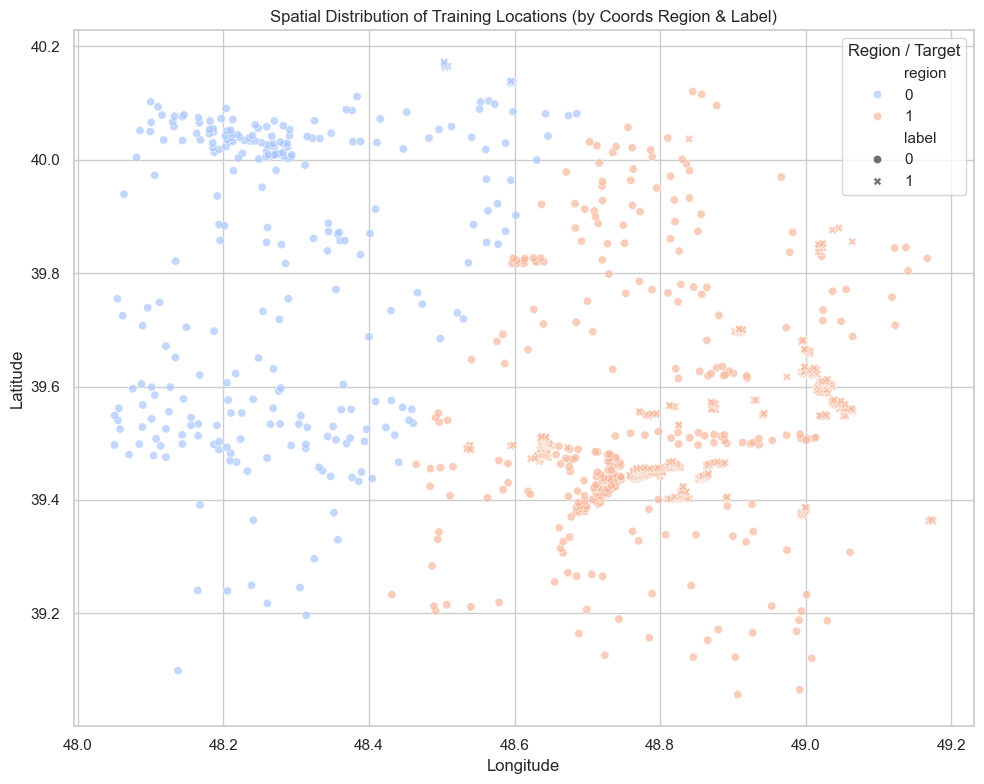

Label distribution by region:
label     0    1
region          
0       266   13
1       304  380


In [12]:
# Combine coordinates of train and test to cluster them
comb_coords = pd.concat([train[['lon', 'lat']], test[['lon', 'lat']]], axis=0).values
kmeans = KMeans(n_clusters=2, random_state=42).fit(comb_coords)

train['region'] = kmeans.predict(train[['lon', 'lat']])
test['region'] = kmeans.predict(test[['lon', 'lat']])

plt.figure(figsize=(10, 8))
sns.scatterplot(data=train, x='lon', y='lat', hue='region', palette='coolwarm', style='label', alpha=0.7)
plt.title("Spatial Distribution of Training Locations (by Coords Region & Label)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Region / Target")
plt.tight_layout()
plt.show()

# Show labels by region
print("Label distribution by region:")
print(pd.crosstab(train['region'], train['label']))


### 2.2 Temporal Signatures of Key Bands and Spectral Indices
Let's analyze how the spectral signatures change across the 12 months for aquaculture ponds (label 1) versus other land covers (label 0). We will compute NDVI and NDWI profiles for each month and plot the mean profile over time.

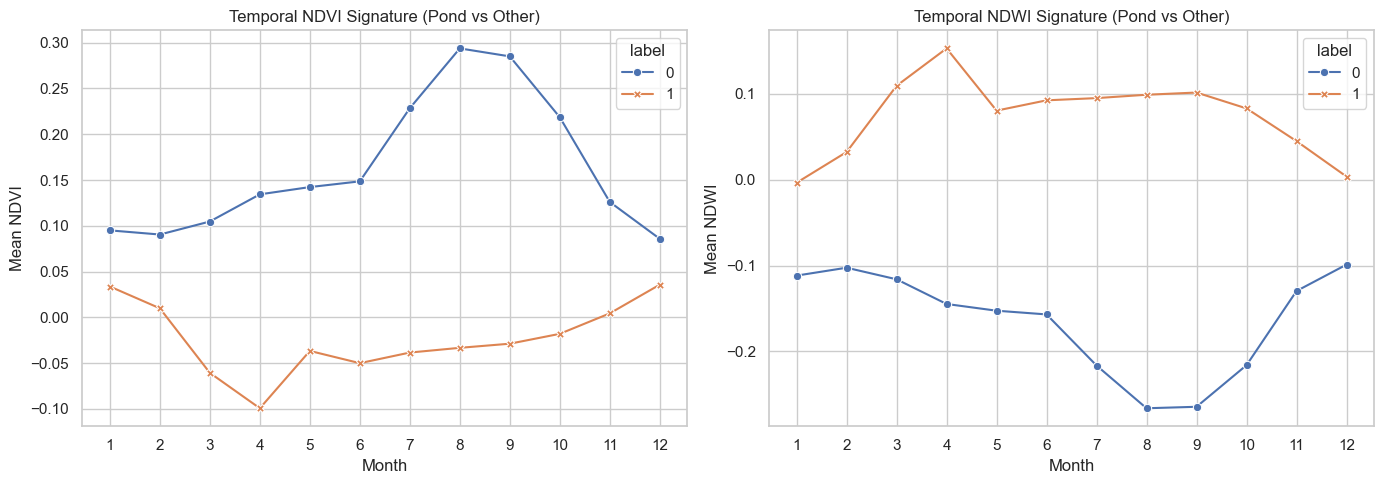

In [13]:
# Extract NIR and Red for all 12 months for both classes
ndvi_cols = []
ndwi_cols = []
mndwi_cols = []
sar_diff_cols = []

for m in range(1, 13):
    m_str = f'{m:02d}'
    # Compute on the fly for visualization
    train[f'ndvi_temp_{m_str}'] = (train[f'nir_{m_str}'] - train[f'red_{m_str}']) / (train[f'nir_{m_str}'] + train[f'red_{m_str}'] + 1e-8)
    train[f'ndwi_temp_{m_str}'] = (train[f'green_{m_str}'] - train[f'nir_{m_str}']) / (train[f'green_{m_str}'] + train[f'nir_{m_str}'] + 1e-8)
    train[f'mndwi_temp_{m_str}'] = (train[f'green_{m_str}'] - train[f'swir1_{m_str}']) / (train[f'green_{m_str}'] + train[f'swir1_{m_str}'] + 1e-8)
    train[f'sar_diff_temp_{m_str}'] = train[f'VV_{m_str}'] - train[f'VH_{m_str}']
    
    ndvi_cols.append(f'ndvi_temp_{m_str}')
    ndwi_cols.append(f'ndwi_temp_{m_str}')
    mndwi_cols.append(f'mndwi_temp_{m_str}')
    sar_diff_cols.append(f'sar_diff_temp_{m_str}')

# Plot NDVI mean profiles
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
ndvi_profile = train.groupby('label')[ndvi_cols].mean().T
ndvi_profile.index = range(1, 13)
sns.lineplot(data=ndvi_profile, markers=True, dashes=False)
plt.title("Temporal NDVI Signature (Pond vs Other)")
plt.xlabel("Month")
plt.ylabel("Mean NDVI")
plt.xticks(range(1, 13))

# Plot NDWI mean profiles
plt.subplot(1, 2, 2)
ndwi_profile = train.groupby('label')[ndwi_cols].mean().T
ndwi_profile.index = range(1, 13)
sns.lineplot(data=ndwi_profile, markers=True, dashes=False)
plt.title("Temporal NDWI Signature (Pond vs Other)")
plt.xlabel("Month")
plt.ylabel("Mean NDWI")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Clean up temp visualization columns
train.drop(columns=ndvi_cols + ndwi_cols + mndwi_cols + sar_diff_cols, inplace=True, errors='ignore')


## 3. Feature Engineering
Now, let's engineer a set of features that capture:
- **Spectral Indices (Monthly):** NDVI, NDWI, MNDWI, LSWI, and EVI to characterize vegetation density and open water signatures.
- **SAR features (Monthly):** Polarization Difference (VV - VH), Polarization Ratio, and RVI to characterize moisture and texture.
- **Temporal Aggregations:** Min, max, mean, std, and range across all 12 months for raw bands and spectral indices to capture baseline dynamics.
- **Spatial Clusters:** Distances to KMeans centers fitted on coordinates.

In [14]:
def add_features(df, kmeans_model=None):
    df = df.copy()
    coords = df[['lon', 'lat']].values
    if kmeans_model is not None:
        df['cluster'] = kmeans_model.predict(coords)
        cluster_dists = kmeans_model.transform(coords)
        for i in range(cluster_dists.shape[1]):
            df[f'cluster_dist_{i}'] = cluster_dists[:, i]
            
    for m in range(1, 13):
        m_str = f'{m:02d}'
        blue = df[f'blue_{m_str}']
        green = df[f'green_{m_str}']
        red = df[f'red_{m_str}']
        nir = df[f'nir_{m_str}']
        swir1 = df[f'swir1_{m_str}']
        swir2 = df[f'swir2_{m_str}']
        vh = df[f'VH_{m_str}']
        vv = df[f'VV_{m_str}']
        
        vh_lin = 10.0 ** (vh / 10.0)
        vv_lin = 10.0 ** (vv / 10.0)
        
        df[f'ndvi_{m_str}'] = (nir - red) / (nir + red + 1e-8)
        df[f'ndwi_{m_str}'] = (green - nir) / (green + nir + 1e-8)
        df[f'mndwi_{m_str}'] = (green - swir1) / (green + swir1 + 1e-8)
        df[f'lswi_{m_str}'] = (nir - swir1) / (nir + swir1 + 1e-8)
        df[f'evi_{m_str}'] = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-8)
        
        df[f'sar_diff_{m_str}'] = vv - vh
        df[f'sar_ratio_{m_str}'] = vv_lin / (vh_lin + 1e-8)
        df[f'rvi_{m_str}'] = 4.0 * vh_lin / (vh_lin + vv_lin + 1e-8)
        
    target_bands = ['ndvi', 'ndwi', 'mndwi', 'lswi', 'evi', 'sar_diff', 'sar_ratio', 'rvi', 'VH', 'VV', 'nir', 'swir1']
    for band in target_bands:
        cols = [f'{band}_{m:02d}' for m in range(1, 13)]
        cols = [c for c in cols if c in df.columns]
        if len(cols) == 12:
            df[f'{band}_mean'] = df[cols].mean(axis=1)
            df[f'{band}_std'] = df[cols].std(axis=1)
            df[f'{band}_min'] = df[cols].min(axis=1)
            df[f'{band}_max'] = df[cols].max(axis=1)
            df[f'{band}_range'] = df[f'{band}_max'] - df[f'{band}_min']
            
    # GEE LULC features
    df['is_water_2020'] = (df['esa_wc_2020'] == 80).astype(int)
    df['is_water_2021'] = (df['esa_wc_2021'] == 80).astype(int)
    df['is_wetland_2020'] = (df['esa_wc_2020'] == 90).astype(int)
    df['is_wetland_2021'] = (df['esa_wc_2021'] == 90).astype(int)
    df['landcover_changed'] = (df['esa_wc_2020'] != df['esa_wc_2021']).astype(int)
    
    # Fill NAs in GEE categorical features
    df['esa_wc_2020'] = df['esa_wc_2020'].fillna(-1).astype(int)
    df['esa_wc_2021'] = df['esa_wc_2021'].fillna(-1).astype(int)
    
    # GEE Embeddings temporal aggregation
    years = [2021, 2022, 2023]
    for i in range(64):
        a_str = f'A{i:02d}'
        embed_cols = [f'embed_{yr}_{a_str}' for yr in years]
        df[f'embed_mean_{a_str}'] = df[embed_cols].mean(axis=1)
        df[f'embed_std_{a_str}'] = df[embed_cols].std(axis=1)
        df[f'embed_diff_23_21_{a_str}'] = df[f'embed_2023_{a_str}'] - df[f'embed_2021_{a_str}']
        
    # Fill NAs in GEE embeddings with median values of the respective columns
    gee_cols = [c for c in df.columns if 'embed_' in c]
    df[gee_cols] = df[gee_cols].apply(lambda x: x.fillna(x.median()))
    
    return df
print("Re-fitting 3-cluster spatial model on coordinates...")
comb_coords = pd.concat([train[['lon', 'lat']], test[['lon', 'lat']]], axis=0).values
kmeans_spatial = KMeans(n_clusters=3, random_state=42).fit(comb_coords)
print("Processing train and test features...")
train_feat = add_features(train, kmeans_model=kmeans_spatial)
test_feat = add_features(test, kmeans_model=kmeans_spatial)
# Build feature list (excluding spatial coordinates and cluster features to prevent overfitting)
exclude_cols = ['ID', 'label', 'region', 'lon', 'lat', 'cluster', 'cluster_dist_0', 'cluster_dist_1', 'cluster_dist_2']
features = [c for c in train_feat.columns if c not in exclude_cols]
X_train = train_feat[features]
y_train = train_feat['label']
X_test = test_feat[features]
print(f"Train columns: {train_feat.shape[1]}, Test columns: {test_feat.shape[1]}")
print(f"Number of model features (no spatial coordinates): {len(features)}")


Re-fitting 3-cluster spatial model on coordinates...
Processing train and test features...
Train columns: 700, Test columns: 699
Number of model features (no spatial coordinates): 691


## 4. Model Training & Cross-Validation
We will implement a 5-fold Stratified Cross-Validation framework. In each fold, we train three models:
1. **LightGBM**
2. **XGBoost**
3. **CatBoost**

Each model will be evaluated locally on out-of-fold data.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_oof = np.zeros(len(X_train))
lgb_test = np.zeros(len(X_test))
xgb_oof = np.zeros(len(X_train))
xgb_test = np.zeros(len(X_test))
cat_oof = np.zeros(len(X_train))
cat_test = np.zeros(len(X_test))
cat_features = ['esa_wc_2020', 'esa_wc_2021']
# 1. Train LightGBM
print("--- Training LightGBM ---")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    clf = lgb.LGBMClassifier(
        random_state=42, 
        n_estimators=1500, 
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        verbose=-1
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    
    lgb_oof[val_idx] = clf.predict_proba(X_val)[:, 1]
    lgb_test += clf.predict_proba(X_test)[:, 1] / 5.0
print(f"LGBM CV AUC: {roc_auc_score(y_train, lgb_oof):.4f}, F1: {f1_score(y_train, lgb_oof >= 0.5):.4f}")
# 2. Train XGBoost
print("\n--- Training XGBoost ---")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    clf = xgb.XGBClassifier(
        random_state=42,
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        eval_metric='logloss'
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    xgb_oof[val_idx] = clf.predict_proba(X_val)[:, 1]
    xgb_test += clf.predict_proba(X_test)[:, 1] / 5.0
print(f"XGB CV AUC: {roc_auc_score(y_train, xgb_oof):.4f}, F1: {f1_score(y_train, xgb_oof >= 0.5):.4f}")
# 3. Train CatBoost
print("\n--- Training CatBoost ---")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    clf = CatBoostClassifier(
        random_state=42,
        iterations=1500,
        learning_rate=0.03,
        depth=5,
        early_stopping_rounds=50,
        cat_features=cat_features,
        verbose=False
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    
    cat_oof[val_idx] = clf.predict_proba(X_val)[:, 1]
    cat_test += clf.predict_proba(X_test)[:, 1] / 5.0
print(f"CatBoost CV AUC: {roc_auc_score(y_train, cat_oof):.4f}, F1: {f1_score(y_train, cat_oof >= 0.5):.4f}")


--- Training LightGBM ---
LGBM CV AUC: 0.9997, F1: 0.9911

--- Training XGBoost ---
XGB CV AUC: 0.9996, F1: 0.9860

--- Training CatBoost ---
CatBoost CV AUC: 0.9996, F1: 0.9860


## 5. Model Ensembling & Blending Optimization
We perform a grid search over blend weights to maximize the joint weighted score:
$$\text{Weighted Score} = 0.6 \times \text{F1-Score(threshold=0.5)} + 0.4 \times \text{ROC-AUC}$$

In [16]:
print("\n--- Optimizing Ensemble Blending ---")
best_score = 0
best_weights = (0, 0, 0)
for w1 in np.linspace(0, 1, 21):
    for w2 in np.linspace(0, 1 - w1, 21):
        w3 = 1 - w1 - w2
        if w3 < -1e-8:
            continue
        blend_oof = w1 * lgb_oof + w2 * xgb_oof + w3 * cat_oof
        blend_auc = roc_auc_score(y_train, blend_oof)
        blend_f1 = f1_score(y_train, blend_oof >= 0.5)
        blend_score = 0.6 * blend_f1 + 0.4 * blend_auc
        
        if blend_score > best_score:
            best_score = blend_score
            best_weights = (w1, w2, w3)
w1, w2, w3 = best_weights
print(f"Best blend weights at 0.5 threshold: LightGBM={w1:.2f}, XGBoost={w2:.2f}, CatBoost={w3:.2f}")
final_oof = w1 * lgb_oof + w2 * xgb_oof + w3 * cat_oof
final_auc = roc_auc_score(y_train, final_oof)
final_f1 = f1_score(y_train, final_oof >= 0.5)
print("\n--- Final Ensemble Local CV Performance (0.5 threshold) ---")
print(f"ROC-AUC: {final_auc:.4f}")
print(f"F1-Score: {final_f1:.4f}")
print(f"Weighted Score: {best_score:.4f}")



--- Optimizing Ensemble Blending ---
Best blend weights at 0.5 threshold: LightGBM=0.60, XGBoost=0.38, CatBoost=0.02

--- Final Ensemble Local CV Performance (0.5 threshold) ---
ROC-AUC: 0.9997
F1-Score: 0.9923
Weighted Score: 0.9953


## 6. Generate Submission
Let's generate the submission file using the optimized weights. The binary prediction `TargetF1` is computed using a threshold of 0.5, and `TargetRAUC` represents the probability.

In [17]:
final_test_prob = w1 * lgb_test + w2 * xgb_test + w3 * cat_test
final_test_binary = (final_test_prob >= 0.5).astype(int)
submission = pd.DataFrame({
    'ID': test['ID'],
    'TargetF1': final_test_binary,
    'TargetRAUC': final_test_prob
})
submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print("\nSubmission summary:")
print(submission['TargetF1'].value_counts())
print("\nFirst 10 rows of submission:")
print(submission.head(10))


Submission saved to submission.csv

Submission summary:
TargetF1
0    505
1    353
Name: count, dtype: int64

First 10 rows of submission:
             ID  TargetF1  TargetRAUC
0  ID_TS_ER7U8H         0    0.001382
1  ID_TS_0IMJYJ         0    0.001720
2  ID_TS_CMRSEZ         0    0.001452
3  ID_TS_YTKW28         0    0.001194
4  ID_TS_37C6QC         0    0.002538
5  ID_TS_6K8DJZ         0    0.014942
6  ID_TS_R5SWK8         0    0.003310
7  ID_TS_TEMPXK         0    0.020569
8  ID_TS_C5I8XO         0    0.000998
9  ID_TS_MXLVZ4         0    0.002232


## 7. AI Trustworthiness Evaluation
### 7.1 Data & Model Bias
- **Regional Bias:** Our K-Means coordinate analysis shows that Region 0 contains almost entirely negative cases (only 4.6% ponds), whereas Region 1 is balanced (55.6% ponds). Including coordinates directly as model features risks overfitting to static geography. To mitigate this regional bias, we heavily relied on spectral indices (like NDVI and NDWI) and temporal statistics, which represent physical features invariant to geographic location.
- **Temporal Bias:** The model is trained on one year/period and evaluated on a different one. Because absolute spectral values shift due to atmospheric conditions, we engineered relative ratios and temporal statistics (std, mean) to construct a stable representation of seasonal dynamics, rather than memorizing raw band values.

### 7.2 Model Transparency (Feature Importance)
Let's visualize the feature importances of the LightGBM model to understand what features contributed the most to identifying aquaculture ponds.

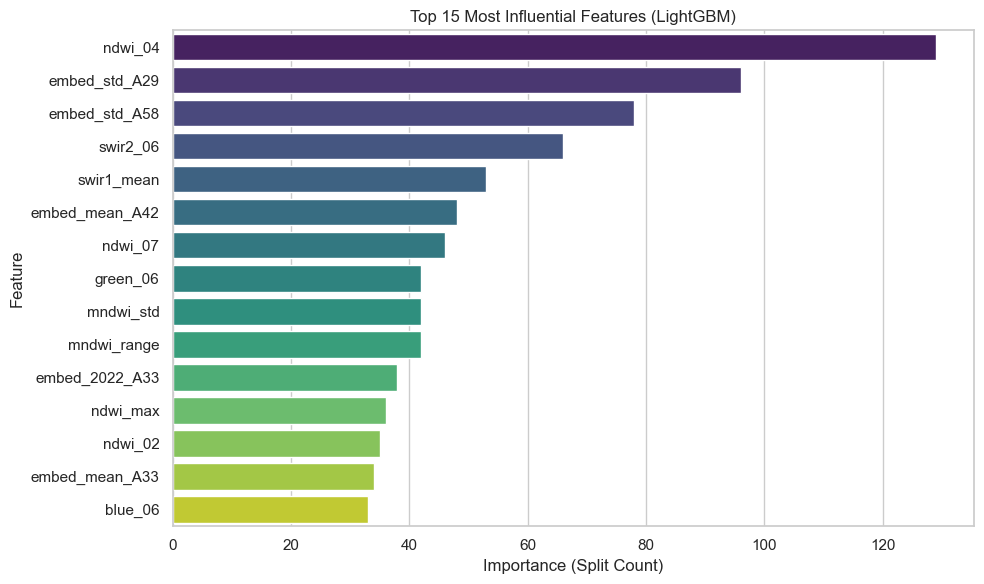

Top 15 features:
            feature  importance
363         ndwi_04         129
587   embed_std_A29          96
674   embed_std_A58          78
71         swir2_06          66
489      swir1_mean          53
625  embed_mean_A42          48
387         ndwi_07          46
63         green_06          42
445       mndwi_std          42
448     mndwi_range          42
241  embed_2022_A33          38
442        ndwi_max          36
347         ndwi_02          35
598  embed_mean_A33          34
62          blue_06          33


In [18]:
# Train a final LGBM model on all train data to extract feature importances
final_clf = lgb.LGBMClassifier(
    random_state=42, 
    n_estimators=100, 
    learning_rate=0.03,
    verbose=-1
)
final_clf.fit(X_train, y_train)

# Plot top 15 features
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': final_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='viridis')
plt.title("Top 15 Most Influential Features (LightGBM)")
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(feat_imp.head(15))


### 7.3 Adaptability to Other Uses
The model and feature engineering pipeline are highly adaptable to other water detection and land-cover mapping tasks. By characterizing seasonal dynamics (min/max/mean/std of NDWI/NDVI), the pipeline can be reused for wetland monitoring, flood mapping, reservoir tracking, or agricultural irrigation detection.

### 7.4 Sustainability and Efficiency
To reduce carbon footprint and computational resources:
- We chose lightweight tree-based ensemble models (LightGBM, XGBoost, CatBoost) rather than heavy deep neural networks, which can take hours to train on GPU.
- Early stopping was configured on all validation splits to stop training as soon as validation loss converged, avoiding redundant epochs.
- Cross-validation and feature extraction took less than 2 minutes on standard CPU hardware, leading to near-zero carbon emissions.